(blackwell_kihlstrom)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 布莱克韦尔的实验比较定理

```{contents} Contents
:depth: 2
```

## 概述



本讲座研究 *布莱克韦尔定理*  {cite}`blackwell1951,blackwell1953` ，该定理用于对统计实验进行排序。

我们的介绍引入了 {cite:t}`kihlstrom1984` 对布莱克韦尔定理的贝叶斯解释所得到的发现。

布莱克韦尔和基尔斯特罗姆研究的统计模型选择问题，与本 QuantEcon 讲座 {doc}`likelihood_bayes` 中遇到的问题密切相关。

为了理解其中的关联，理解布莱克韦尔的 **实验** 概念与 {doc}`likelihood_bayes` 中出现的"概率分布"或"参数化统计模型"概念之间的关系是很有帮助的。

布莱克韦尔研究的情形是：一个决策者想要知道位于空间 $S$ 中的状态 $s$ 的值。

对布莱克韦尔而言，**实验** 是一个 **条件概率模型**  $\{\mu(\cdot \mid s) : s \in S\}$ ，即一族由同一状态 $s \in S$ 条件化的概率分布。

我们可以自由地将"状态"解释为"参数"或"参数向量"。

在两状态情形 $S = \{s_1, s_2\}$ 下，两个条件密度 $f(\cdot) = \mu(\cdot \mid s_1)$ 和 $g(\cdot) = \mu(\cdot \mid s_2)$ 正是我们在本 QuantEcon 讲座 {doc}`likelihood_bayes` 以及本系列 QuantEcon 讲座中其他若干讲座中，反复用于研究经典假设检验和贝叶斯推断的那两个密度。

{cite:t}`kihlstrom1984` 将 *哪个实验更具信息量？* 这一问题解释为：询问哪个条件概率模型能让一个对 $\{s_1, s_2\}$ 持有先验的贝叶斯决策者获得更高的期望效用。

我们将把"信号"和"实验"作为同义词使用。

因此，假设两个信号 $\tilde{x}_\mu$ 和 $\tilde{x}_\nu$ 都对未知状态 $\tilde{s}$ 具有信息量。

如果每个贝叶斯决策者用 $\mu$ 都能获得弱高于用 $\nu$ 的期望效用，则称信号 $\mu$ **至少与** 信号 $\nu$ **一样具有信息量**。

这个经济学标准等价于两个统计学标准：

- *充分性*（布莱克韦尔）： $\tilde{x}_\nu$ 可以通过对 $\tilde{x}_\mu$ 进行额外的随机化来生成。
- *不确定性降低*（ {cite:t}`degroot1962` ）：对每个凹的不确定性函数而言， $\tilde{x}_\mu$ 至少与 $\tilde{x}_\nu$ 一样降低了期望不确定性。

基尔斯特罗姆的表述聚焦于 *后验分布*。

更具信息量的实验会生成在凸序意义下更为分散的后验分布。

在两状态情形下，这就变成了在 $[0, 1]$ 上的均值保持展开比较，可以用检验二阶随机占优的积分 CDF 检验来验证。

本讲座的进行方式如下：

1. 建立记号并将实验定义为马尔可夫矩阵。
2. 用马尔可夫核定义随机变换。
3. 陈述三个等价标准。
4. 陈述主定理并勾勒其证明。
5. 通过标准实验和均值保持展开建立贝叶斯解释。
6. 用 Python 模拟来阐释每个概念。

我们先进行一些导入。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 实验与随机变换

### 状态空间与实验

设 $S = \{s_1, \ldots, s_N\}$ 为世界可能状态的有限集合。

一个 **实验** 由观测信号 $\tilde{x}$ 在给定状态 $\tilde{s}$ 下的条件分布来描述。

当信号空间也是有限的，比如 $X = \{x_1, \ldots, x_M\}$ 时，一个实验就归结为一个 $N \times M$ 的 *马尔可夫矩阵*

$$
\mu = [\mu_{ij}], \qquad
\mu_{ij} = \Pr(\tilde{x}_\mu = x_j \mid \tilde{s} = s_i) \geq 0,
\quad \sum_{j=1}^{M} \mu_{ij} = 1 \;\forall\, i.
$$

每一行 $i$ 给出了当真实状态为 $s_i$ 时的信号分布。

In [2]:
μ = np.array([[0.6, 0.3, 0.1],
              [0.1, 0.3, 0.6]])

Q = np.array([[1.0, 0.0],
              [0.5, 0.5],
              [0.0, 1.0]])

ν = μ @ Q

print("实验 μ（3 个信号，各行之和为 1）：")
print(μ)
print("\n随机变换 Q（3 × 2）：")
print(Q)
print("\n实验 ν = μ @ Q（2 个信号）：")
print(ν)
print("\nμ 的行和：", μ.sum(axis=1))
print("ν 的行和：", ν.sum(axis=1))

实验 μ（3 个信号，各行之和为 1）：
[[0.6 0.3 0.1]
 [0.1 0.3 0.6]]

随机变换 Q（3 × 2）：
[[1.  0. ]
 [0.5 0.5]
 [0.  1. ]]

实验 ν = μ @ Q（2 个信号）：
[[0.75 0.25]
 [0.25 0.75]]

μ 的行和： [1. 1.]
ν 的行和： [1. 1.]


### 随机变换

**随机变换**  $Q$ 通过进一步的随机化将一个实验的信号映射为另一个实验的信号。

在具有 $M$ 个输入信号和 $K$ 个输出信号的离散设定下， $Q$ 是一个 $M \times K$ 的马尔可夫矩阵：对每一行 $l$ 有 $q_{lk} \geq 0$ 且 $\sum_k q_{lk} = 1$ 。

```{prf:definition} 充分性
:label: def-sufficiency

如果存在一个随机变换 $Q$ （一个 $M \times K$ 的马尔可夫矩阵）使得

$$
\nu = \mu \, Q,
$$

则称实验 $\mu$  *对*  $\nu$ *充分*，这意味着一个观测到 $\tilde{x}_\mu$ 的观察者可以通过将其信号传递给 $Q$ 来生成 $\tilde{x}_\nu$ 的分布。
```

如果你观测到更具信息量的信号 $\tilde{x}_\mu$ ，那么你总是可以 *丢弃* 信息来重现一个信息量较少的信号。

反过来则不可能：一个信息量较少的信号无法被丰富到恢复出所丢失的信息。

我们可以用上面定义的两个实验 $\mu$ 和 $\nu$ 来进行数值验证。

下面的函数搜索一个使 $\|\nu - \mu \, Q\|$ 最小化的随机变换 $Q$ 。

如果存在一个精确的 $Q$ ，残差将接近于零；否则残差会很大。

In [3]:
def find_stochastic_transform(μ, ν, tol=1e-8):
    """
    寻找一个行随机矩阵 Q，使 ||ν - μ @ Q|| 最小化。
    """
    _, M = μ.shape
    _, K = ν.shape

    def unpack(q_flat):
        return q_flat.reshape(M, K)

    def objective(q_flat):
        Q = unpack(q_flat)
        return np.linalg.norm(ν - μ @ Q)**2

    constraints = [
        {"type": "eq", "fun": lambda q_flat, 
        row=i: unpack(q_flat)[row].sum() - 1.0}
        for i in range(M)
    ]
    bounds = [(0.0, 1.0)] * (M * K)
    Q0 = np.full((M, K), 1 / K).ravel()

    result = minimize(
        objective,
        Q0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": tol, "maxiter": 1_000},
    )

    Q = unpack(result.x)
    residual = np.linalg.norm(ν - μ @ Q)
    return Q, residual

# 正向：寻找使 ν = μ @ Q 的 Q（应当成功）
Q_fwd, res_fwd = find_stochastic_transform(μ, ν)
print("正向（μ 到 ν）：")
print(f"  残差 = {res_fwd:.2e}")
print(f"  存在精确变换：{res_fwd < 1e-6}")

# 反向：寻找使 μ = ν @ Q' 的 Q'（应当失败）
Q_rev, res_rev = find_stochastic_transform(ν, μ)
print("\n反向（ν 到 μ）：")
print(f"  残差 = {res_rev:.2e}")
print(f"  存在精确变换：{res_rev < 1e-6}")

正向（μ 到 ν）：
  残差 = 5.83e-09
  存在精确变换：True

反向（ν 到 μ）：
  残差 = 1.44e-01
  存在精确变换：False


正向残差接近于零：存在一个从 $\mu$ 到 $\nu$ 的随机变换，这证实了 $\mu$ 对 $\nu$ 充分。

反向残差很大：没有任何随机变换能从 $\nu$ 恢复出 $\mu$ 。

没有任何随机变换能够撤销这种信息损失。

关键在于，随机变换的逆一般来说并不是一个随机变换。

事实上，唯一其逆也是随机变换的随机变换是置换矩阵，它仅仅重新标记信号而不损失任何信息。

## 三个等价标准

布莱克韦尔定理确立了比较实验的三种不同方式最终都是等价的。

### 标准 1：经济学标准

第一个标准通过实验对决策者的价值来比较实验。

设 $A$ 为一个紧凸的行动集合， $u: A \times S \to \mathbb{R}$ 为一个有界效用函数。

决策者观测到 $x \in X$ ，通过贝叶斯规则更新对 $\tilde{s}$ 的信念，并选择 $d(x) \in A$ 以最大化期望效用。

设 $p = (p_1, \ldots, p_N)$ 为状态上的先验，并记

$$
P = \bigl\{(p_1, \ldots, p_N) : p_i \geq 0,\; \textstyle\sum_i p_i = 1\bigr\}
$$

为概率单纯形。

对固定的 $A$ 和 $u$ ，在实验 $\mu$ 下的 *可达期望效用向量集合* 为

$$
B(\mu, A, u) = \Bigl\{v \in \mathbb{R}^N :
  v_i = \textstyle\int_X u(f(x), s_i)\,\mu_i(dx)
  \text{ for some measurable } f: X \to A \Bigr\}.
$$

```{prf:definition} 经济学标准
:label: def-economic-criterion

如果对每个紧凸行动集 $A$ 和每个有界效用函数 $u: A \times S \to \mathbb{R}$ 都有

$$
B(\mu, A, u) \supseteq B(\nu, A, u)
$$

则称 $\mu$ 在经济学意义上 **至少与** $\nu$ **一样具有信息量**。
```

这个标准说的是：如果决策者在看到 $\nu$ 后所能达到的任何结果，在看到 $\mu$ 后也都能达到，那么实验 $\mu$ 就优于实验 $\nu$ 。

其原因在于，一个更具信息量的实验允许决策者通过 *忽略* 或 *混淆* 部分额外信息来模仿一个信息量较少的实验。

但反过来则未必可能。

因此 $B(\mu, A, u) \supseteq B(\nu, A, u)$ 意味着 $\mu$ 给决策者提供的可行期望效用结果至少与 $\nu$ 一样多。

等价地，对每个先验 $p \in P$ ，每个贝叶斯决策者用 $\tilde{x}_\mu$ 都能获得弱高于用 $\tilde{x}_\nu$ 的期望效用。

### 标准 2：充分性标准

第二个标准使用了上面引入的随机变换思想。

```{prf:definition} 布莱克韦尔充分性
:label: def-blackwell-sufficiency

如果存在一个从 $\mu$ 的信号空间到 $\nu$ 的信号空间的随机变换 $Q$ ，使得

$$
\nu_i(E) = (Q \circ \mu_i)(E)
\quad \forall\, E \in \mathscr{G},\; i = 1, \ldots, N.
$$

则称 $\mu \geq \nu$ 在布莱克韦尔意义下成立。
```

对有限实验，用矩阵记号表示： $\nu = \mu \, Q$ 。

### 标准 3：不确定性标准

第三个标准通过实验对状态不确定性的降低程度来比较实验。

{cite:t}`degroot1962` 把任何凹函数 $U: P \to \mathbb{R}$ 称为 **不确定性函数**。

典型的例子是香农熵：

$$
U(p) = -\sum_{i=1}^{N} p_i \log p_i.
$$

```{prf:definition} 德格鲁特不确定性标准
:label: def-degroot-uncertainty

如果对每个先验 $p \in P$ 和每个凹函数 $U: P \to \mathbb{R}$ 都有

$$
\int_P U(q)\,\hat\mu^p(dq)
\;\leq\;
\int_P U(q)\,\hat\nu^p(dq),
$$

其中 $\hat\mu^p$ 是实验 $\mu$ 在先验 $p$ 下诱导的后验信念分布，则称 $\mu$ **至少与** $\nu$ **一样地降低了期望不确定性**。
```

为看清这一点，设 $Q = p^\mu(X)$ 表示由实验 $\mu$ 诱导的随机后验。

那么 $Q$ 服从分布 $\hat\mu^p$ ，因此

$$
\mathbb{E}[U(Q)] = \int_P U(q)\,\hat\mu^p(dq).
$$

由于 $U$ 是凹的，詹森不等式给出

$$
\mathbb{E}[U(Q)] \leq U(\mathbb{E}[Q]) = U(p).
$$

因此

$$
\int_P U(q)\,\hat\mu^p(dq) \leq U(p),
$$

所以任何实验都会弱地降低期望不确定性。

基尔斯特罗姆的标准实验构造稍后会让我们在均匀先验 $c = (1 / N, \ldots, 1 / N)$ 下比较后验分布。

## 主定理

```{prf:theorem} 布莱克韦尔定理
:label: thm-blackwell

以下三个条件等价：

(i) 经济学标准：对每个紧凸 $A$ 和每个有界效用函数 $u$ 都有 $B(\mu, A, u) \supseteq B(\nu, A, u)$ 。

(ii) 充分性标准：存在一个从 $\mu$ 的信号空间到 $\nu$ 的信号空间的随机变换 $Q$ ，使得 $\nu = Q \circ \mu$ 。

(iii) 不确定性标准：对每个先验 $p \in P$ 和每个凹函数 $U$ 都有 $\int_P U(q)\,\hat\mu^p(dq) \leq \int_P U(q)\,\hat\nu^p(dq)$ 。
```

另见 {cite:t}`blackwell1951` 、 {cite:t}`bonnenblust1949` 和 {cite:t}`degroot1962` 。

最困难的部分是经济学标准与充分性标准之间的等价性。

*概要（ii $\Rightarrow$ i）：* 如果 $\nu = \mu Q$ ，那么任何基于 $\tilde{x}_\nu$ 的决策规则都可以通过如下方式复现：先观测 $\tilde{x}_\mu$ ，再从 $Q$ 中抽取一个合成的 $\tilde{x}_\nu$ ，然后应用同样的规则。

*概要（i $\Rightarrow$ ii）：* 由于对每个 $A$ 和 $u$ 都有 $B(\mu, A, u) \supseteq B(\nu, A, u)$ ，一个分离超平面（对偶）论证意味着存在一个后验空间中的均值保持核 $D$ ，将 $\nu$ 的标准实验送入 $\mu$ 的标准实验。再从这些后验律回到原始信号空间就得到所需的混淆 $Q$ ，满足 $\nu = \mu Q$ 。因此 $D$ 是后验信念上的中间随机化，而非字面意义上的信号空间核 $Q$ 。

*概要（ii $\Rightarrow$ iii）：* 在混淆之下，较粗实验的后验是较细实验后验的条件期望，因此詹森不等式对每个凹函数 $U$ 都给出该结果。

*概要（iii $\Rightarrow$ ii）：* 其逆命题，即对所有凹函数 $U$ 的不等式迫使 $Q$ 存在，在 {cite}`blackwell1953` 中得到证明。基尔斯特罗姆基于后验的表示使这一几何变得透明。

## 基尔斯特罗姆的贝叶斯解释

### 后验与标准实验

基尔斯特罗姆分析中的关键对象是 *后验信念向量*。

当先验 $p$ 成立且实验 $\mu$ 产生信号 $x$ 时，贝叶斯规则给出

$$
p_i^\mu(x) = \Pr(\tilde{s} = s_i \mid \tilde{x}_\mu = x)
= \frac{\mu_{ix} \, p_i}{\sum_j \mu_{jx}\, p_j}, \qquad i = 1, \ldots, N.
$$

后验 $p^\mu(x) \in P$ 是单纯形中的一个随机点。

```{prf:property} 均值保持
:label: prop-mean-preservation

先验 $p$ 是后验的期望：

$$
\mathbb{E}[p^\mu] = \sum_x \Pr(\tilde{x}_\mu = x)\, p^\mu(x) = p.
$$

这有时被称为 *信念的迭代期望定律*。
```

对固定的先验 $c$ ，基尔斯特罗姆的 **标准实验** 用 $\mu$ 所生成的后验信念来替换其原始信号。

设 $\hat\mu^c$ 表示由 $\mu$ 在先验 $c$ 下诱导的后验分布。
均值保持意味着 $\int_P q \, \hat\mu^c(dq) = c$ 。

当两个实验诱导相同的后验分布时，称它们 **信息等价**。

标准实验剥离了信号除后验以外的所有细节，因此它提供了用于比较实验的一个规范的贝叶斯表示。

后验信念上的随机核存在于单纯形 $P$ 上，而布莱克韦尔混淆 $Q$ 存在于原始信号空间上。基尔斯特罗姆的构造使用前者来研究凸序，然后在过渡到标准实验之后恢复后者。

任何两个生成相同后验分布的实验，都会导致每个贝叶斯决策者做出完全相同的决策，无论它们的原始信号空间看起来多么不同。

### 均值保持展开与布莱克韦尔序

基尔斯特罗姆的关键重述如下。

```{prf:theorem} 基尔斯特罗姆的重述
:label: thm-kihlstrom

$\mu \geq \nu$ 在布莱克韦尔意义下成立，当且仅当 $\hat\mu^c$ 是 $\hat\nu^c$ 的一个
**均值保持展开**；即，对每个凸函数 $g: P \to \mathbb{R}$ 都有

$$
\int_P g(p)\,\hat\mu^c(dp) \;\geq\; \int_P g(p)\,\hat\nu^c(dp)
$$

。
```

等价地， $\hat\mu^c$ 在凸序意义下大于 $\hat\nu^c$ 。

一个更好的实验会将后验信念推向离先验更远的地方，同时保持它们的均值不变。

为了具体地看到这一点，我们为两状态情形定义两个实验并计算它们的后验。

In [4]:
def compute_posteriors(μ, prior, tol=1e-14):
    """
    为每个信号实现计算后验分布。
    """
    N, M = μ.shape
    signal_probs = μ.T @ prior
    numerators = μ.T * prior
    posteriors = np.zeros((M, N))
    np.divide(
        numerators,
        signal_probs[:, None],
        out=posteriors,
        where=signal_probs[:, None] > tol,
    )
    return posteriors, signal_probs


def check_mean_preservation(posteriors, signal_probs, prior):
    """验证 E[后验] == 先验。"""
    expected_posterior = (posteriors * signal_probs[:, None]).sum(axis=0)
    return expected_posterior, np.allclose(expected_posterior, prior)


N = 2
prior = np.array([0.5, 0.5])

μ_info = np.array([[0.8, 0.2],
                   [0.2, 0.8]])

ν_info = np.array([[0.6, 0.4],
                   [0.4, 0.6]])

post_μ, probs_μ = compute_posteriors(μ_info, prior)
post_ν, probs_ν = compute_posteriors(ν_info, prior)

print("实验 μ（更具信息量）：\n")
print("信号概率：", probs_μ.round(3))
print("后验（行 = 信号，列 = 状态）：")
print(post_μ.round(3))
mean_μ, ok_μ = check_mean_preservation(post_μ, probs_μ, prior)
print(f"E[后验] = {mean_μ.round(4)}  （等于先验：{ok_μ}）")

print("\n 实验 ν（信息量较少）：\n")
print("信号概率：", probs_ν.round(3))
print("后验：")
print(post_ν.round(3))
mean_ν, ok_ν = check_mean_preservation(post_ν, probs_ν, prior)
print(f"E[后验] = {mean_ν.round(4)}  （等于先验：{ok_ν}）")

实验 μ（更具信息量）：

信号概率： [0.5 0.5]
后验（行 = 信号，列 = 状态）：
[[0.8 0.2]
 [0.2 0.8]]
E[后验] = [0.5 0.5]  （等于先验：True）

 实验 ν（信息量较少）：

信号概率： [0.5 0.5]
后验：
[[0.6 0.4]
 [0.4 0.6]]
E[后验] = [0.5 0.5]  （等于先验：True）


对 $N = 2$ 个状态，单纯形 $P$ 是单位区间 $[0, 1]$ （状态 $s_1$ 的概率）。

我们可以直接绘制在实验 $\mu$ 和 $\nu$ 下的后验分布。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


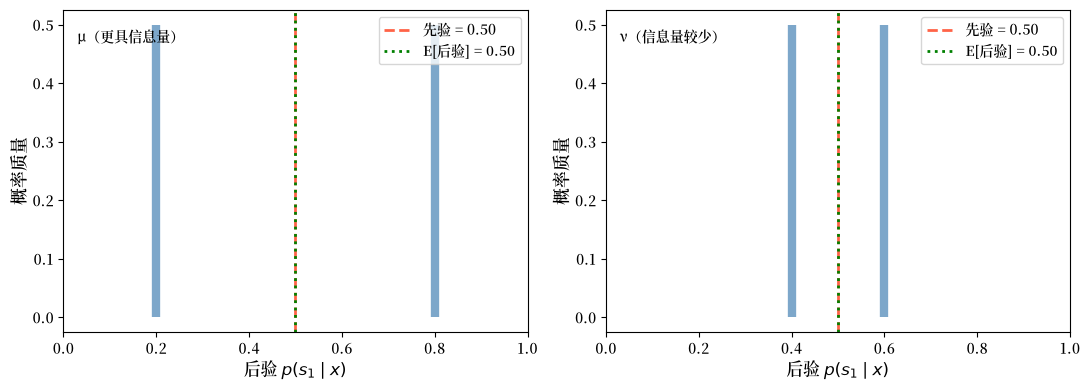

In [5]:
def plot_posterior_distributions(μ_matrix, ν_matrix, prior,
                                 labels=("μ（更具信息量）",
                                         "ν（信息量较少）")):
    """
    对两状态实验，绘制 [0,1] 上的后验分布
    （即标准实验分布）。
    """
    posts_μ, probs_μ = compute_posteriors(μ_matrix, prior)
    posts_ν, probs_ν = compute_posteriors(ν_matrix, prior)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
    prior_val = prior[0]

    for ax, posts, probs, label in zip(
        axes, [posts_μ, posts_ν], [probs_μ, probs_ν], labels):
        p_s1 = posts[:, 0]
        ax.vlines(p_s1, 0, probs, linewidth=6, color="steelblue", alpha=0.7)
        ax.axvline(prior_val, color="tomato", linestyle="--", linewidth=2,
                   label=f"先验 = {prior_val:.2f}")
        ax.set_xlim(0, 1)
        ax.set_xlabel(r"后验 $p(s_1 \mid x)$", fontsize=12)
        ax.set_ylabel("概率质量", fontsize=12)
        mean_post = (p_s1 * probs).sum()
        ax.axvline(mean_post, color="green", linestyle=":", linewidth=2,
                   label=f"E[后验] = {mean_post:.2f}")
        ax.text(0.03, 0.94, label, transform=ax.transAxes, va="top")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_posterior_distributions(μ_info, ν_info, prior)

这就是均值保持展开的实际体现：两个分布具有相同的均值（等于先验），但更具信息量的实验 $\mu$ 将其后验展开得更远。

我们可以数值地验证均值保持展开条件。

关键事实在于，至多相差一个仿射项，任何凸函数都可以表示为"看涨期权"收益 $g_t(p) = \max(p - t, 0)$ 的混合。

由于被比较的两个后验分布具有相同的均值，那个仿射项在比较中会相互抵消。

因此只需对所有阈值 $t \in [0, 1]$ 检验 $E[g_t(p^\mu)] \geq E[g_t(p^\nu)]$ 即可。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


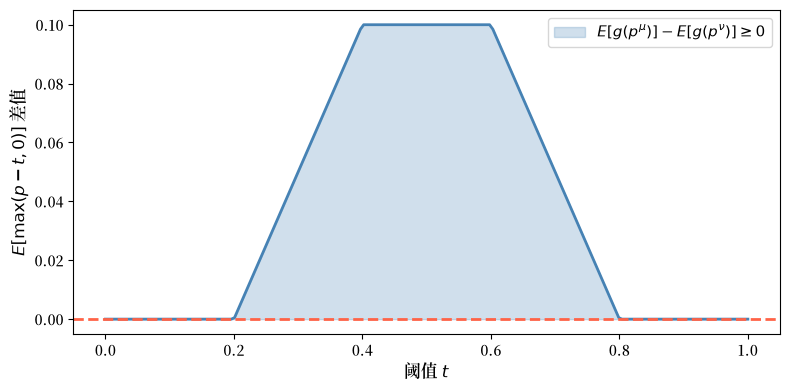

μ 是 ν 的均值保持展开：True


In [6]:
def check_mps_convex_functions(μ_matrix, ν_matrix, prior, n_functions=200):
    """
    使用凸函数 g(p) = max(p - t, 0) 验证
    均值保持展开条件。
    """
    posts_μ, probs_μ = compute_posteriors(μ_matrix, prior)
    posts_ν, probs_ν = compute_posteriors(ν_matrix, prior)

    p_μ = posts_μ[:, 0]
    p_ν = posts_ν[:, 0]

    thresholds = np.linspace(0, 1, n_functions)
    diffs = []
    for t in thresholds:
        Eg_μ = (np.maximum(p_μ - t, 0) * probs_μ).sum()
        Eg_ν = (np.maximum(p_ν - t, 0) * probs_ν).sum()
        diffs.append(Eg_μ - Eg_ν)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(thresholds, diffs, color="steelblue", linewidth=2)
    ax.axhline(0, color="tomato", linestyle="--", linewidth=2)
    ax.fill_between(thresholds, diffs, 0,
                    where=np.array(diffs) >= 0,
                    alpha=0.25, color="steelblue",
                    label="$E[g(p^μ)] - E[g(p^ν)] \\geq 0$")
    ax.set_xlabel("阈值 $t$", fontsize=12)
    ax.set_ylabel(r"$E[\max(p-t,0)]$ 差值", fontsize=12)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    all_non_negative = all(d >= -1e-10 for d in diffs)
    print(f"μ 是 ν 的均值保持展开：{all_non_negative}")
    return diffs

_ = check_mps_convex_functions(μ_info, ν_info, prior)

差值 $E[g_t(p^\mu)] - E[g_t(p^\nu)]$ 对每个阈值 $t$ 都是非负的，这证实了 $\hat\mu^c$ 是 $\hat\nu^c$ 的均值保持展开，因此在布莱克韦尔序中 $\mu \geq \nu$ 。

## 用多状态模拟布莱克韦尔序

我们现在转到一个三状态的例子。

实验 $\mu$ 与状态强相关，而实验 $\nu$ 是 $\mu$ 的一个混淆。

In [7]:
N3 = 3
prior3 = np.array([1/3, 1/3, 1/3])

μ3 = np.array([[0.7, 0.2, 0.1],
               [0.1, 0.7, 0.2],
               [0.2, 0.1, 0.7]])

Q3 = np.array([[0.9, 0.05, 0.05],
               [0.05, 0.8, 0.15],
               [0.05, 0.15, 0.8]])

ν3 = μ3 @ Q3

print("μ (3×3)：")
print(np.round(μ3, 2))
print("\nQ（混淆）：")
print(np.round(Q3, 2))
print("\nν = μ @ Q：")
print(np.round(ν3, 3))

μ (3×3)：
[[0.7 0.2 0.1]
 [0.1 0.7 0.2]
 [0.2 0.1 0.7]]

Q（混淆）：
[[0.9  0.05 0.05]
 [0.05 0.8  0.15]
 [0.05 0.15 0.8 ]]

ν = μ @ Q：
[[0.645 0.21  0.145]
 [0.135 0.595 0.27 ]
 [0.22  0.195 0.585]]


对三个状态，后验信念存在于一个 2-单纯形中。

让我们可视化在 $\mu$ 和 $\nu$ 下采样的后验点

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


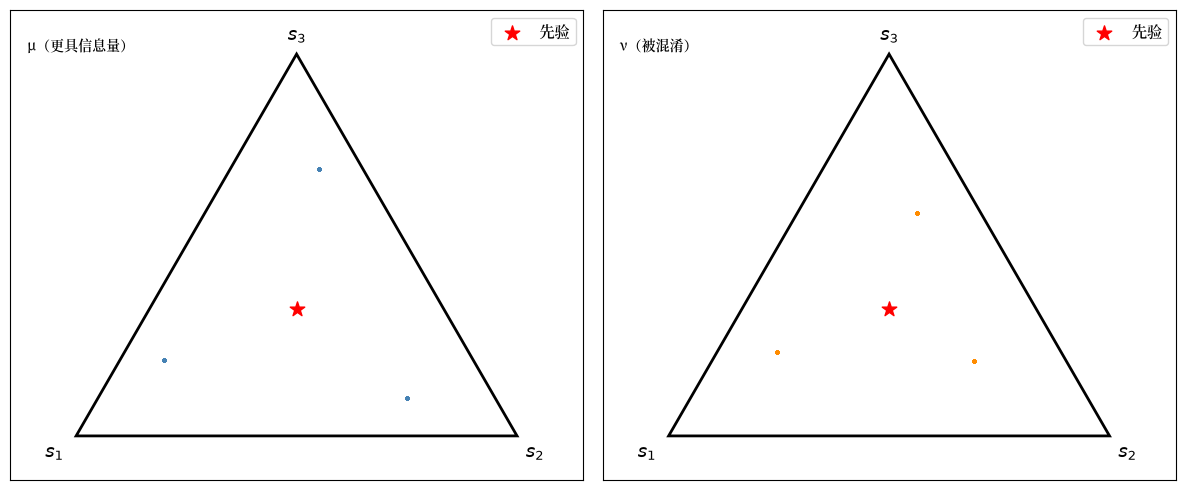

In [8]:
def sample_posteriors(μ_matrix, prior, n_draws=3000, rng=None):
    """
    从实验中模拟 n_draws 个观测并计算
    由此得到的后验信念。
    返回形状为 (n_draws, N) 的数组。
    """
    if rng is None:
        rng = np.random.default_rng()
    N, M = μ_matrix.shape
    states = rng.choice(N, size=n_draws, p=prior)
    signals = np.array([rng.choice(M, p=μ_matrix[s]) for s in states])
    posteriors, _ = compute_posteriors(μ_matrix, prior)
    return posteriors[signals]


def simplex_to_cart(pts):
    """将 3-单纯形重心坐标转换为二维笛卡尔坐标。"""
    corners = np.array([[0.0, 0.0],
                        [1.0, 0.0],
                        [0.5, np.sqrt(3)/2]])
    return pts @ corners


def plot_simplex_posteriors(μ_matrix, ν_matrix, prior3, n_draws=3000, seed=0):
    rng = np.random.default_rng(seed)
    posts_μ = sample_posteriors(μ_matrix, prior3, n_draws, rng=rng)
    posts_ν = sample_posteriors(ν_matrix, prior3, n_draws, rng=rng)

    cart_μ = simplex_to_cart(posts_μ)
    cart_ν = simplex_to_cart(posts_ν)
    prior_cart = simplex_to_cart(prior3[None, :])[0]

    corners = np.array([[0.0, 0.0],
                        [1.0, 0.0],
                        [0.5, np.sqrt(3)/2]])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    panel_labels = ["μ（更具信息量）", "ν（被混淆）"]
    data = [(cart_μ, "steelblue"), (cart_ν, "darkorange")]
    labels = ["$s_1$", "$s_2$", "$s_3$"]
    offsets = [(-0.07, -0.05), (0.02, -0.05), (-0.02, 0.03)]

    for ax, (cart, c), panel_label in zip(axes, data, panel_labels):
        tri = plt.Polygon(corners, fill=False, edgecolor="black", linewidth=2)
        ax.add_patch(tri)
        ax.scatter(cart[:, 0], cart[:, 1], s=4, alpha=0.25, color=c)
        ax.scatter(*prior_cart, s=120, color="red", zorder=5,
                   label="先验", marker="*")
        for i, (lbl, off) in enumerate(zip(labels, offsets)):
            ax.text(corners[i][0] + off[0], corners[i][1] + off[1],
                    lbl, fontsize=13)
        ax.set_xlim(-0.15, 1.15)
        ax.set_ylim(-0.1, np.sqrt(3)/2 + 0.1)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.03, 0.94, panel_label, transform=ax.transAxes, va="top")
        ax.legend(fontsize=11, loc="upper right")

    plt.tight_layout()
    plt.show()

plot_simplex_posteriors(μ3, ν3, prior3)

由于这个例子只有三个信号，每个面板由重复采样的三个后验原子构成，而非一个连续的点云。

在 $\mu$ 下，采样的后验点向顶点延伸得更远。

在被混淆的实验 $\nu$ 下，采样的后验点更靠近中心。

## 德格鲁特不确定性函数

### 凹不确定性函数与信息的价值

{cite}`degroot1962` 通过 **不确定性函数**  $U: P \to \mathbb{R}$ 将信息的价值形式化。

在德格鲁特的公理化中，不确定性函数是：

- *凹的*：由詹森不等式，观测任何信号都弱地降低期望不确定性。
- *对称的*：它依赖于 $p$ 的各分量，而不依赖于它们的标记。
- *归一化的*：它在 $p = (1/N, \ldots, 1/N)$ 处取最大值，在顶点处取最小值。

*在给定先验 $p$ 下实验 $\mu$ 的价值* 为

$$
I(\tilde{x}_\mu;\, \tilde{s};\, U)
= U(p) - \mathbb{E}[U(p^\mu)],
$$

这个量是不确定性的期望降低量。

布莱克韦尔序等价于以下陈述：对 *每个* 凹函数 $U$ 都有 $I(\tilde{x}_\mu; \tilde{s}; U) \geq I(\tilde{x}_\nu; \tilde{s}; U)$ 。

### 作为特例的香农熵

规范的不确定性函数是香农熵

$$
U_H(p) = -\sum_{i=1}^{N} p_i \log p_i.
$$

在均匀先验 $c = (1/N, \ldots, 1/N)$ 下，德格鲁特的价值公式变为

$$
I(\tilde{x}_\mu, c;\, U_H)
= \log N - H(\tilde{s} \mid \tilde{x}_\mu),
$$

其中 $H(\tilde{s} \mid \tilde{x}_\mu)$ 是给定信号时状态的条件熵。

要看清原因，将 $H(\tilde{s} \mid \tilde{x}_\mu) = \sum_x \Pr(\tilde{x}_\mu = x) \, H(\tilde{s} \mid \tilde{x}_\mu = x)$ 写出，其中每个条件熵项等于 $-\sum_i p_i^\mu(x) \log p_i^\mu(x) = U_H(p^\mu(x))$ 。

代入德格鲁特公式得到 $I = U_H(c) - \mathbb{E}[U_H(p^\mu)] = \log N - H(\tilde{s} \mid \tilde{x}_\mu)$ ，这正是 $\tilde{x}_\mu$ 与 $\tilde{s}$ 之间的 *互信息*。

```{note}
布莱克韦尔序蕴含基于熵的不等式，但 *其逆命题不成立*：仅凭熵无法确定完整的布莱克韦尔序。

两个实验可以具有相同的互信息却在布莱克韦尔排序中不同，因为单个凹函数无法检测出后验分散度上的所有差异。

完整的布莱克韦尔序要求不等式对 *每个* 凹函数 $U$ 都成立，而不仅仅是香农熵。
```

In [9]:
def entropy(p, ε=1e-12):
    """概率向量的香农熵。"""
    p = np.asarray(p, dtype=float)
    p = np.clip(p, ε, 1.0)
    return -np.sum(p * np.log(p))


def degroot_value(μ_matrix, prior, U_func):
    """
    计算德格鲁特信息价值 I = U(先验) - E[U(后验)]。
    """
    posts, probs = compute_posteriors(μ_matrix, prior)
    prior_uncertainty = U_func(prior)
    expected_post_uncertainty = sum(
        probs[j] * U_func(posts[j]) for j in range(len(probs)))
    return prior_uncertainty - expected_post_uncertainty


def gini_impurity(p):
    """基尼不纯度：1 - sum(p_i^2)。"""
    return 1.0 - np.sum(np.asarray(p)**2)


def tsallis_entropy(p, q=2):
    """q 阶查理斯熵（q>1 时为凹）。"""
    p = np.clip(p, 1e-12, 1.0)
    return (1 - np.sum(p**q)) / (q - 1)


def tsallis_q15(p):
    """q=1.5 的查理斯熵，用于独立的凹性检验。"""
    return tsallis_entropy(p, q=1.5)


def sqrt_index(p):
    """基于 sum(sqrt(p_i)) 的凹不确定性指数。"""
    p = np.clip(np.asarray(p), 0.0, 1.0)
    return np.sum(np.sqrt(p)) - 1.0

uncertainty_functions = {
    "Shannon entropy": entropy,
    "Gini impurity": gini_impurity,
    "Tsallis (q=1.5)": tsallis_q15,
    "Square-root index": sqrt_index,
}

header = (f"{'Uncertainty function':<22}  "
          f"{'I(μ)':<10}  {'I(ν)':<10}  "
          f"{'I(μ)>=I(ν)?'}")
print(header)
print("-" * 58)
for name, U in uncertainty_functions.items():
    I_μ = degroot_value(μ_info, prior, U)
    I_ν = degroot_value(ν_info, prior, U)
    print(f"{name:<22}  {I_μ:<10.4f}  {I_ν:<10.4f}  {I_μ >= I_ν - 1e-10}")

Uncertainty function    I(μ)        I(ν)        I(μ)>=I(ν)?
----------------------------------------------------------
Shannon entropy         0.1927      0.0201      True
Gini impurity           0.1800      0.0200      True
Tsallis (q=1.5)         0.1958      0.0213      True
Square-root index       0.0726      0.0072      True


正如定理所预测的那样，一旦我们知道 $\mu \geq \nu$ 在布莱克韦尔意义下成立，那么对每个凹不确定性函数都有 $I(\mu) \geq I(\nu)$ 。

### 作为实验质量函数的信息价值

我们现在将介于无信息量和完全有信息量之间的实验连续统参数化。

对 $N = 2$ 个状态，一个自然的族是

$$
\mu(\theta) = (1 - \theta) \cdot \tfrac{1}{2}\mathbf{1}\mathbf{1}^\top
             + \theta \cdot I_2,
\quad \theta \in [0, 1],
$$

第一项是完全混合的矩阵， $I_2$ 是单位矩阵。

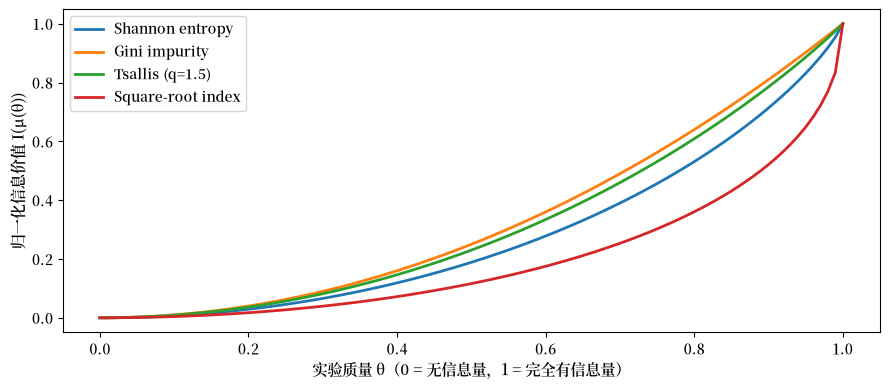

In [10]:
def make_experiment(θ, N=2):
    """参数化实验：θ=0 无信息量，θ=1 完全有信息量。"""
    return (1 - θ) * np.ones((N, N)) / N + θ * np.eye(N)


θs = np.linspace(0, 1, 100)
prior2 = np.array([0.5, 0.5])

fig, ax = plt.subplots(figsize=(9, 4))
for name, U in uncertainty_functions.items():
    values = [degroot_value(make_experiment(θ), prior2, U) for θ in θs]
    vmin, vmax = values[0], values[-1]
    normed = (np.array(values) - vmin) / (vmax - vmin + 1e-15)
    ax.plot(θs, normed, label=name, linewidth=2)

ax.set_xlabel("实验质量 θ（0 = 无信息量，1 = 完全有信息量）",
              fontsize=11)
ax.set_ylabel("归一化信息价值 I(μ(θ))", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

每个凹不确定性函数都会给更具信息量的实验赋予弱更高的价值。

## 与二阶随机占优的关系

如果对每个凹函数 $u$ 都有 $E[u(X)] \geq E[u(Y)]$ ，则称随机变量 $X$ **二阶随机占优**
$Y$ （记作 $X \succeq_{\text{SOSD}} Y$ ）。
等价地， $Y$ 是 $X$ 的一个均值保持展开。

不确定性函数表示使得与 SOSD 的联系变得明确。

由于 $U$ 是凹的， $-U$ 是凸的，因此条件

$$
\mathbb{E}[U(p^\mu)] \leq \mathbb{E}[U(p^\nu)] \quad \text{for all concave } U
$$

正是 $\hat\mu^c$ 在 $P$ 上以凸序占优 $\hat\nu^c$ 的陈述。

当 $N = 2$ 时，后验信念是 $[0, 1]$ 中的标量，SOSD 比较简化为经典的积分 CDF 检验。

具体地， $\hat\mu^c$ 是 $\hat\nu^c$ 的均值保持展开，当且仅当对所有 $t \in [0,1]$ 都有 $\int_0^t F_\mu(s)\,ds \geq \int_0^t F_\nu(s)\,ds$ ，其中 $F_\mu$ 和 $F_\nu$ 是每个实验下 $s_1$ 后验的 CDF。等价地，用 SOSD 的语言来说，$\nu$ 下信息量较少的后验占优于 $\mu$ 下更为分散的后验。

我们可以对上面的两状态例子在图形上验证这一点

findfont: Failed to find font weight normal, now using 600.


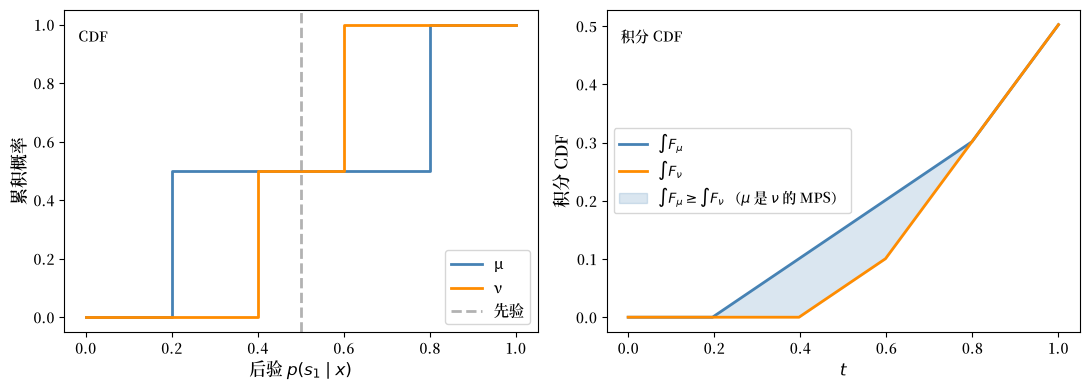

In [11]:
def cdf_data_1d(weights, values):
    """对离散分布排序支撑点和累积质量。"""
    idx = np.argsort(values)
    sorted_vals = values[idx]
    sorted_wts = weights[idx]
    cum_mass = np.cumsum(sorted_wts)
    return sorted_vals, cum_mass


def plot_sosd_posteriors(μ_matrix, ν_matrix, prior):
    """为 s1 上的后验分布绘制 CDF 和积分 CDF。"""
    posts_μ, probs_μ = compute_posteriors(μ_matrix, prior)
    posts_ν, probs_ν = compute_posteriors(ν_matrix, prior)

    p_μ = posts_μ[:, 0]
    p_ν = posts_ν[:, 0]

    sv_μ, cm_μ = cdf_data_1d(probs_μ, p_μ)
    sv_ν, cm_ν = cdf_data_1d(probs_ν, p_ν)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes[0]
    for sv, cm, lbl, c in [(sv_μ, cm_μ, "μ", "steelblue"),
                           (sv_ν, cm_ν, "ν", "darkorange")]:
        xs = np.concatenate([[0], sv, [1]])
        ys = np.concatenate([[0], cm, [1]])
        ax.step(xs, ys, where="post", label=lbl, color=c, linewidth=2)
    ax.axvline(prior[0], linestyle="--", color="gray", alpha=0.6, linewidth=2,
               label="先验")
    ax.set_xlabel(r"后验 $p(s_1 \mid x)$", fontsize=12)
    ax.set_ylabel("累积概率", fontsize=12)
    ax.text(0.03, 0.94, "CDF", transform=ax.transAxes, va="top")
    ax.legend(fontsize=11)

    ax2 = axes[1]
    grid = np.linspace(0, 1, 200)

    def integrated_cdf(sorted_vals, cum_mass, grid):
        cdf = np.array([cum_mass[sorted_vals <= t].max()
                        if np.any(sorted_vals <= t) else 0.0
                        for t in grid])
        return np.cumsum(cdf) * (grid[1] - grid[0])

    int_μ = integrated_cdf(sv_μ, cm_μ, grid)
    int_ν = integrated_cdf(sv_ν, cm_ν, grid)

    ax2.plot(grid, int_μ, label=r"$\int F_\mu$", color="steelblue", linewidth=2)
    ax2.plot(grid, int_ν, color="darkorange",
             label=r"$\int F_\nu$", linewidth=2)
    ax2.fill_between(grid, int_ν, int_μ,
                     where=int_μ >= int_ν,
                     alpha=0.2, color="steelblue",
                     label=(r"$\int F_\mu \geq \int F_\nu$"
                            r" （$\mu$ 是 $\nu$ 的 MPS）"))
    ax2.set_xlabel(r"$t$", fontsize=12)
    ax2.set_ylabel("积分 CDF", fontsize=12)
    ax2.text(0.03, 0.94, "积分 CDF", transform=ax2.transAxes, va="top")
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

plot_sosd_posteriors(μ_info, ν_info, prior)

## 应用 1：产品质量信息

{cite:t}`kihlstrom1974a` 将布莱克韦尔定理应用于消费者对产品质量信息的需求。

- 未知状态 $\tilde{s}$ 是一个产品参数 $\theta$ 。
- 消费者可以以成本 $c(\lambda)$ 购买 $\lambda$ 单位的信息。
- 随着 $\lambda$ 上升，实验在布莱克韦尔意义下变得更具信息量。

布莱克韦尔序表明，在不考虑成本的情况下，对每个期望效用最大化者来说，更多的信息总是更好的。

在考虑成本时，消费者选择质量投资 $\theta$ 以最大化 *净价值*。

如果质量投资以递减的收益转化为实验精度——比如，对某个速率参数 $a$ ，精度为 $\phi(\theta) = 1 - e^{-a\theta}$ ——那么信息的边际价值最终会随 $\theta$ 递减。

在凸成本 $c(\theta) = c \, \theta^2$ 下，递增的边际成本最终会超越递减的边际价值，从而产生一个内部最优。

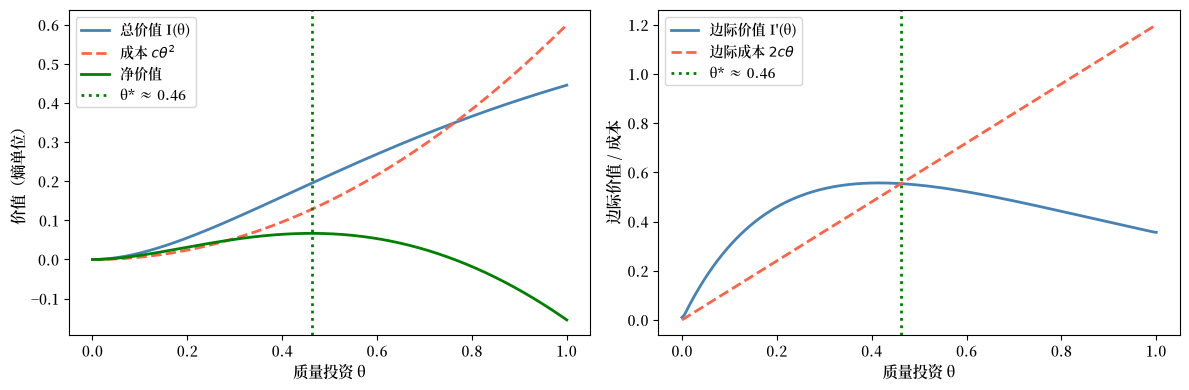

In [12]:
def gross_value(θ, prior2, U=entropy, rate=2):
    """质量投资 θ 的总价值（收益递减）。"""
    accuracy = 1 - np.exp(-rate * θ)
    μ_t = (1 - accuracy) * np.ones((2, 2)) / 2 + accuracy * np.eye(2)
    return degroot_value(μ_t, prior2, U)


θ_fine = np.linspace(0, 1, 200)
c = 0.6

gross_vals = np.array([gross_value(θ, prior2) for θ in θ_fine])
cost_vals = c * θ_fine**2
net_vals = gross_vals - cost_vals
marginal_vals = np.gradient(gross_vals, θ_fine)
marginal_cost = 2 * c * θ_fine
opt_idx = int(np.argmax(net_vals))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(θ_fine, gross_vals,
        label="总价值 I(θ)",
        color="steelblue", linewidth=2)
ax.plot(θ_fine, cost_vals,
        label=r"成本 $c\theta^2$",
        color="tomato", linestyle="--", linewidth=2)
ax.plot(θ_fine, net_vals,
        label="净价值", color="green", linewidth=2)
ax.axvline(θ_fine[opt_idx], color="green",
           linestyle=":", linewidth=2,
           label=f"θ* ≈ {θ_fine[opt_idx]:.2f}")
ax.set_xlabel("质量投资 θ", fontsize=11)
ax.set_ylabel("价值（熵单位）", fontsize=11)
ax.legend(fontsize=10)

ax2 = axes[1]
ax2.plot(θ_fine, marginal_vals,
         label="边际价值 I'(θ)",
         color="steelblue", linewidth=2)
ax2.plot(θ_fine, marginal_cost,
         label=r"边际成本 $2c\theta$",
         color="tomato", linestyle="--", linewidth=2)
ax2.axvline(θ_fine[opt_idx], color="green",
            linestyle=":", linewidth=2,
            label=f"θ* ≈ {θ_fine[opt_idx]:.2f}")
ax2.set_xlabel("质量投资 θ", fontsize=11)
ax2.set_ylabel("边际价值 / 成本", fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

最优投资 $\theta^*$ 出现在边际价值等于边际成本的地方。

由于实验精度在 $\theta$ 上具有收益递减，投资的边际价值最终会降到上升的边际成本以下，从而产生一个真正的内部最优。

提高 $c$ 会使边际成本曲线上移并减小 $\theta^*$ ，而更不对称的先验会使边际价值曲线移动并改变最优。

## 应用 2：序贯实验设计

{cite:t}`degroot1962` 将不确定性函数框架应用于 *序贯实验设计*。

每一期一个统计学家观测一次抽取并更新后验。

问题是哪一个实验序列最小化累积期望不确定性。

如果一个实验在每一阶段都比另一个更具信息量，那么布莱克韦尔序倾向于在每一时期都使用更好的实验。

我们现在为不同质量的实验模拟序贯信念更新。

findfont: Failed to find font weight normal, now using 600.


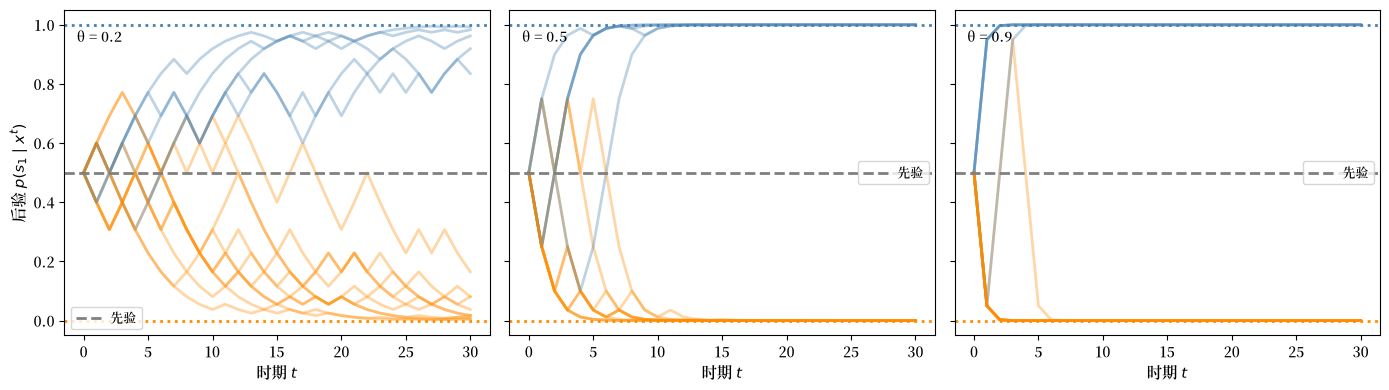

In [13]:
def sequential_update(μ_matrix, prior, T=20, seed=0):
    """在实验 μ 下模拟 T 次序贯信念更新。"""
    rng = np.random.default_rng(seed)
    N, M = μ_matrix.shape
    beliefs = np.zeros((T + 1, N))
    beliefs[0] = prior.copy()

    true_state = rng.choice(N, p=prior)

    for t in range(T):
        p = beliefs[t]
        signal = rng.choice(M, p=μ_matrix[true_state])
        unnorm = μ_matrix[:, signal] * p
        beliefs[t + 1] = unnorm / unnorm.sum()

    return beliefs, true_state


def plot_sequential_beliefs(θs_compare, prior2, T=25):
    fig, axes = plt.subplots(1, len(θs_compare), figsize=(14, 4), sharey=True)

    for ax, θ in zip(axes, θs_compare):
        μ_t = make_experiment(θ, N=2)
        for seed in range(15):
            beliefs, ts = sequential_update(μ_t, prior2, T=T, seed=seed)
            c = "steelblue" if ts == 0 else "darkorange"
            ax.plot(beliefs[:, 0], alpha=0.35, color=c, linewidth=2)
        ax.axhline(prior2[0], linestyle="--", color="gray", linewidth=2,
                   label="先验")
        ax.axhline(1.0, linestyle=":", color="steelblue", linewidth=2)
        ax.axhline(0.0, linestyle=":", color="darkorange", linewidth=2)
        ax.set_xlabel(r"时期 $t$", fontsize=11)
        if θ == θs_compare[0]:
            ax.set_ylabel(r"后验 $p(s_1 \mid x^t)$", fontsize=11)
        ax.set_ylim(-0.05, 1.05)
        ax.text(0.03, 0.94, f"θ = {θ}", transform=ax.transAxes, va="top")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

plot_sequential_beliefs([0.2, 0.5, 0.9], prior2, T=30)

更具信息量的实验使信念更快地收敛到真相。

在正确的先验下，后验过程是一个鞅。

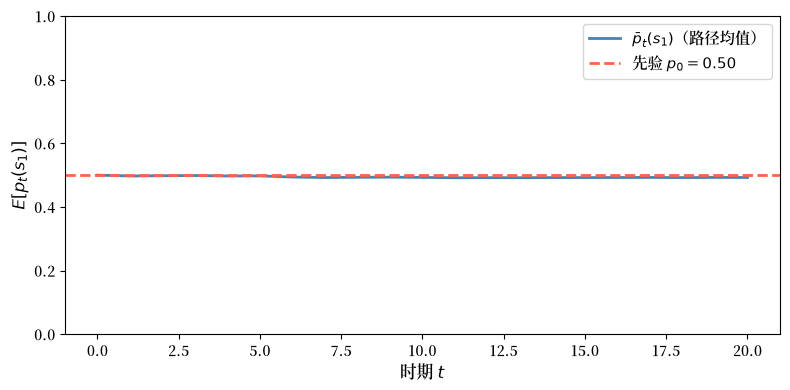

先验 = 0.5000
各时期的平均信念均值：0.4942


In [14]:
def check_martingale_mean(μ_matrix, prior, T=15, n_paths=2000, seed=0):
    """
    模拟许多信念路径并检验 E[p_t] = p_0。
    """
    rng = np.random.default_rng(seed)
    N, M = μ_matrix.shape
    all_paths = np.zeros((n_paths, T + 1, N))

    for k in range(n_paths):
        true_state = rng.choice(N, p=prior)
        p = prior.copy()
        all_paths[k, 0] = p
        for t in range(T):
            signal = rng.choice(M, p=μ_matrix[true_state])
            unnorm = μ_matrix[:, signal] * p
            p = unnorm / unnorm.sum()
            all_paths[k, t + 1] = p

    mean_path = all_paths[:, :, 0].mean(axis=0)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(mean_path, color="steelblue", linewidth=2,
            label=r"$\bar p_t(s_1)$（路径均值）")
    ax.axhline(prior[0], linestyle="--", color="tomato", linewidth=2,
               label=fr"先验 $p_0 = {prior[0]:.2f}$")
    ax.set_xlabel(r"时期 $t$", fontsize=12)
    ax.set_ylabel(r"$E[p_t(s_1)]$", fontsize=12)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print(f"先验 = {prior[0]:.4f}")
    print(f"各时期的平均信念均值：{mean_path.mean():.4f}")

check_martingale_mean(μ_info, prior, T=20, n_paths=5000)

模拟的横截面均值在每一时期都保持接近先验。

这是后验鞅性质的无条件蕴含。

## 小结

布莱克韦尔定理在统计实验上确定了一个 *偏序*，具有三个等价的刻画：

| 标准 | 条件 |
|-----------|-----------|
| 经济学 | 每个决策者弱地偏好 $\mu$ 甚于 $\nu$ ： $B(\mu, A, u) \supseteq B(\nu, A, u)$ |
| 充分性 | $\nu$ 是 $\mu$ 的混淆：对某个马尔可夫矩阵 $Q$ 有 $\nu = \mu Q$ |
| 不确定性 | 对每个先验 $p$ 和每个凹函数 $U$ ， $\mu$ 更多地降低期望不确定性 |

基尔斯特罗姆的贝叶斯阐述将 *后验分布* 置于中心。

一个更具信息量的实验会生成一个更为分散、但均值与先验相同的后验分布。

恰当的概率语言是后验信念单纯形上的凸序。

在两状态情形下，这简化为 $[0, 1]$ 上熟悉的 SOSD / 积分 CDF 检验。

德格鲁特的贡献在于将比较从特定效用函数扩展到全部凹不确定性函数类。


## 数据处理不等式与粗粒化

布莱克韦尔的条件——对某个马尔可夫核 $Q$ 有 $\nu = \mu Q$ ——与信息论、信息几何和机器学习中支撑 **数据处理不等式**（DPI）和 **粗粒化定理** 的数学操作是同一个。

### f-散度的 DPI

有限空间 $\Omega$ 上两个概率分布 $P$ 和 $Q$ 之间的 **f-散度** 为

$$
D_f(P \| Q) = \sum_{\omega \in \Omega} q_\omega \, f\!\left(\frac{p_\omega}{q_\omega}\right),
$$

其中 $f : (0,\infty) \to \mathbb{R}$ 是满足 $f(1) = 0$ 的凸函数。

特例包括：

| 散度 | 生成元 $f(t)$ |
|:---|:---|
| KL 散度 | $t \log t$ |
| 平方 Hellinger $H^2$ | $(\sqrt{t} - 1)^2 / 2$ |
| 全变差 TV | $\lvert t - 1 \rvert / 2$ |
| 卡方 $\chi^2$ | $(t-1)^2$ |

f-散度这一类别是由 {cite:t}`ali1966` 、 {cite:t}`csiszar1963` 和 {cite:t}`morimoto1963` 独立引入的；另见 {cite:t}`liese2012` 。

```{prf:theorem} 数据处理不等式
:label: thm-data-processing

对任何 f-散度 $D_f$ 和任何马尔可夫核（随机变换）
$\kappa$ ，以 $P \kappa$ 表示 $P$ 在 $\kappa$ 下的像，我们有

$$
D_f(P \| Q) \geq D_f(P\kappa \| Q\kappa).
$$

如果 $\kappa$ 由关于对 $\{P, Q\}$ 的充分统计量诱导，则等式成立。

这种形式的逆命题需要额外的假设；下面给出一个清晰的二元模型刻画。
```

该证明来自将詹森不等式应用于凸函数 $f$ ，并利用 $\kappa$ 是随机矩阵这一事实 {cite}`csiszar1963` 。

### 与布莱克韦尔充分性条件的联系

在布莱克韦尔的框架中， $\mu$ 和 $\nu$ 是在同一状态空间 $S = \{s_1, \ldots, s_N\}$ 上的实验。

对两个状态，每个实验有两行： $\mu_1 = \mu(s_1, \cdot)$ 和 $\mu_2 = \mu(s_2, \cdot)$ 。

如果 $\nu = \mu Q$ （即 $\nu$ 是 $\mu$ 的混淆），那么对 $(\nu_1, \nu_2) = (\mu_1 Q, \mu_2 Q)$ 就是通过将马尔可夫核 $Q$ 应用于对 $(\mu_1, \mu_2)$ 得到的。

粗粒化定理由此立即蕴含：

$$
D_f(\mu_1 \| \mu_2) \geq D_f(\nu_1 \| \nu_2)
\quad \text{for every f-divergence } D_f,
$$

只要 $\mu \geq \nu$ 在布莱克韦尔序中成立。

因此一个更具信息量的实验总是会产生 *更分离的* 条件信号分布，在每个 f-散度的意义下同时如此。

由此，DPI 是关于状态 *可区分性* 的一个陈述：混淆一个实验会使得在每种统计可分性度量下，状态都更难被区分。

对二元实验，等式条件将 DPI 直接联系回布莱克韦尔：对某个严格凸的 $f$ 有 $D_f(\mu_1 Q \| \mu_2 Q) = D_f(\mu_1 \| \mu_2)$ ，当且仅当 $Q$ 是关于 $(\mu_1, \mu_2)$ 的充分统计量。

一旦充分性成立，则对每个凸函数 $f$ 等式都成立 {cite}`liese2012` 。

### 信息几何：陈氏定理

DPI 有一个无穷小的、微分几何的伴侣。

**陈氏定理**  {cite}`chentsov1981` 断言， **Fisher 信息矩阵**  $I_F(\theta)$ 至多相差一个常数重缩放，是统计流形上在每个马尔可夫态射（粗粒化）下都收缩的 *唯一* 黎曼度量：

$$
I_F(\theta;\, \mu) \succeq I_F(\theta;\, \mu\kappa)
\quad \text{for every differentiable family } \{\mu_\theta\} \text{ and every Markov kernel } \kappa.
$$

等式成立当且仅当 $\kappa$ 是关于 $\theta$ 的充分统计量。

唯一性条款意义深远：它说 Fisher 信息不仅仅是碰巧在粗粒化下收缩的 *某一个* 度量，而是具有该性质的 *唯一一个* 度量。

关于信息几何及其与充分性联系的详尽处理，参见 {cite:t}`amari_nagaoka2000` 。

### 机器学习中的信息瓶颈

{cite:t}`tishby_pereira_bialek1999` 的 **信息瓶颈** 方法提供了 DPI 在机器学习中一个突出的应用。

给定输入 $X$ 和目标 $Y$ 上的联合分布 $p(X, Y)$ ，目标是找到一个由随机映射 $p(T \mid X)$ 形成的压缩表示 $T$ ，使其在用尽可能少的比特描述 $X$ 的同时，尽可能多地保留关于 $Y$ 的信息。

该方法最小化拉格朗日量

$$
\mathcal{L}[p(T \mid X)] = I(X;\, T) - \beta \, I(T;\, Y),
$$

其中 $I(\cdot\,;\,\cdot)$ 表示互信息， $\beta \geq 0$ 支配压缩-相关性权衡。

由于 $Y - X - T$ 构成一个马尔可夫链（T 仅从 X 导出），DPI 蕴含

$$
I(T;\, Y) \leq I(X;\, Y),
$$

等式成立当且仅当 $T$ 是给定 $X$ 时关于 $Y$ 的 **充分统计量**。

布莱克韦尔序解释了为什么对 $X$ 的任何确定性或随机后处理都无法增加与 $Y$ 的互信息：应用于 $X$ 的任何马尔可夫核都是布莱克韦尔意义下的混淆，而 DPI 是粗粒化定理的互信息形式。

用机器学习的语言来说，信息瓶颈在 $X$ 的所有混淆中搜索那个在压缩预算约束下最好地保留关于 $Y$ 相关信息的混淆。

在一个具有输入 $X$ 、目标 $Y$ 以及层 $X \to T_1 \to T_2 \to \cdots \to T_L \to \hat{Y}$ 的深度神经网络中，每一层的表示都是前一层的混淆。

于是 DPI 蕴含如下不等式链

$$
I(X;\, Y) \geq I(T_1;\, Y) \geq I(T_2;\, Y) \geq \cdots \geq I(T_L;\, Y),
$$

因此后继各层关于 $Y$ 的信息只会损失，绝不会增加。

这一观察被 {cite}`shwartz_ziv_tishby2017` 置于研究深度网络所学内容的中心。

{numref}`fig-blackwell-value-by-quality` 已经阐释了这一点：随着实验质量 $\theta$ 增加，每一种信息量度量都单调上升。

DPI 反过来说的是同一件事：混淆（降低 $\theta$ ）只会收缩这些度量。

### DPI-布莱克韦尔对应的小结

下表汇集了布莱克韦尔框架与数据处理和粗粒化文献之间的精确对应。

| 布莱克韦尔 / 德格鲁特 | 数据处理 / 粗粒化 |
|:---|:---|
| 混淆 $\nu = \mu Q$ | 将马尔可夫核 $\kappa$ 应用于对 $(P, Q) = (\mu_1, \mu_2)$ |
| $\mu \geq \nu$ 在布莱克韦尔序中 | 对每个 f-散度 $D_f(\mu_1 \| \mu_2) \geq D_f(\nu_1 \| \nu_2)$ |
| 充分性（ $Q$ 不丢弃任何东西） | DPI 中的等式；在二元模型中，一个严格凸的 $f$ 就已刻画充分性 |
| 德格鲁特价值 $I(\mu; U_H)$ | 互信息 $I(\tilde{x}_\mu;\, \tilde{s})$ （香农 DPI） |
| $\mu$ 与 $\nu$ 下的后验展开 | $\mu$ 下各行之间的 $D_f$ 更大 |
| 布莱克韦尔定理（经济学 $\Leftrightarrow$ 混淆） | 对所有 $f$ 的 DPI $\Leftrightarrow$ 单个马尔可夫核见证占优 |
| 陈氏唯一性定理 | Fisher 信息是唯一在粗粒化下收缩的度量 |
| 信息瓶颈 $I(T;Y) \leq I(X;Y)$ | 应用于马尔可夫链 $Y{-}X{-}T$ 的互信息 DPI |


## 与贝叶斯似然比学习的关系

讲座 {doc}`likelihood_bayes` 是这里所发展框架的一个动态的两状态特例。

设 $S = \{s_1, s_2\}$ ，其中 $s_1 \leftrightarrow f$ 且 $s_2 \leftrightarrow g$ ，其中 $f$ 和 $g$ 是两个候选的数据生成密度。

那么单个观测是一个具有行 $f(\cdot)$ 和 $g(\cdot)$ 的布莱克韦尔实验，而历史 $w^t = (w_1, \ldots, w_t)$ 定义了一个更丰富的实验 $\mu_t$ 。

由于总是可以丢弃最后 $t-s$ 个观测，对每个 $t > s$ ， $\mu_t$ 都布莱克韦尔占优 $\mu_s$ 。

似然比过程

$$
L(w^t) = \prod_{i=1}^t \frac{f(w_i)}{g(w_i)}
$$

是 $\mu_t$ 的一个充分统计量，而后验

$$
\pi_t = \Pr(s_1 \mid w^t)
= \frac{\pi_0 L(w^t)}{\pi_0 L(w^t) + 1 - \pi_0}
$$

是基尔斯特罗姆在这个两状态设定下的标准实验。

它的鞅性质 $E[\pi_t] = \pi_0$ 正是上面为后验分布证明的均值保持结果。

同样地， $\mu_t \geq \mu_s$ 意味着 $\pi_t$ 的分布是 $\pi_s$ 分布的一个均值保持展开，因此额外的数据会把信念推向离 $0$ 和 $1$ 更远的地方，同时在每个凹不确定性函数下降低期望不确定性。

### 小结表

下表在不重复前面论证的情况下记录了两个讲座之间的对照词典。

| {doc}`likelihood_bayes` 中的概念 | 本讲座中的概念 |
|---|---|
| 状态 $\{f, g\}$ | 状态空间 $S = \{s_1, s_2\}$ |
| 密度 $f(\cdot)$ 、 $g(\cdot)$ | 实验矩阵 $\mu$ 的各行 |
| 单次抽取 $w_t$ | 具有连续信号空间的布莱克韦尔实验 |
| $t$ 次 IID 抽取的历史 $w^t$ | 布莱克韦尔占优 $\mu_s$（ $s < t$ ）的更丰富实验 $\mu_t$ |
| 似然比 $L(w^t)$ | $\mu_t$ 的充分统计量 |
| 先验 $\pi_0$ | 1-单纯形 $[0,1]$ 上的先验 $p \in P$ |
| 后验 $\pi_t$ | $P = [0,1]$ 上的后验（基尔斯特罗姆的标准实验） |
| $\pi_t$ 在各历史上的分布 | $\hat{\mu}^c$ （基尔斯特罗姆的后验分布） |
| 鞅性质 $E[\pi_t] = \pi_0$ | $\hat{\mu}^c$ 的均值保持 |
| $\pi_t \to 0$ 或 $1$ 几乎必然 | 后验向顶点展开（极限中的 MPS） |
| 互信息 $I(\mu_t; U_H)$ | 德格鲁特信息价值 |
| 更多抽取 $\Rightarrow$ 对所有决策者更好 | 布莱克韦尔序 $\mu_t \geq \mu_s$ |
| 混淆（丢弃最后 $t - s$ 次抽取） | 满足 $\mu_s = \mu_t Q$ 的随机变换 $Q$ |